In [1]:
%load_ext autoreload
%autoreload 2

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from mb_dataset import MBDataset
from mb_calculator import MullerBrownPotential
import os
calculator = MullerBrownPotential(device = "cpu")

dataset = MBDataset(preload_sim_dir="diffusion_data_new/temp=700_timestep=5.0_friction=0.001", device = "cuda:6")


Loading simulations from directory: diffusion_data_new/temp=700_timestep=5.0_friction=0.001


100%|██████████| 305/305 [00:42<00:00,  7.13it/s]


In [25]:
device = torch.device("cuda:6")


def plot_samples(samples: np.ndarray, committor_probs: np.ndarray, plot_transition = True, title: str = "Muller Brown Samples") -> None:
    # plot a single plot with samples
    fig, ax = plt.subplots()
    num_points = 100
    x_values = torch.linspace(calculator.Lx, calculator.Hx , num_points)
    y_values = torch.linspace(calculator.Ly, calculator.Hy, num_points)

    x, y = torch.meshgrid(x_values, y_values, indexing = "xy")
    z = calculator.U_split(x, y).cpu()
    
        
    # colorbar = ax.imshow(z, extent=(x_values.min(), x_values.max(), y_values.min(), y_values.max()), vmin=calculator.U_min, vmax=calculator.U_max, origin='lower', cmap='viridis', aspect='auto')
    
    scatter1 = ax.scatter(samples[:, 0], samples[:, 1], s = 0.3, c = committor_probs, cmap='coolwarm')
    plt.colorbar(scatter1, ax=ax, label='Committor Probability')

    if plot_transition:
        transition_mask = torch.logical_and(committor_probs > 0.45 , committor_probs < 0.55).reshape(-1)
        ax.scatter(samples[transition_mask, 0], samples[transition_mask, 1], c = "green", label = "Transition")

    ax.set_xlim([calculator.Lx, calculator.Hx])
    ax.set_ylim([calculator.Ly, calculator.Hy])
    plt.title(title)
    plt.show()
    plt.close()

def linear_warmup_cosine_decay_lr_scheduler(optimizer, warmup_steps, total_steps, lr_min=0.0, lr_max=1.0):
    """
    Linear warmup with cosine decay 
    """
    def lr_lambda(current_step: int):
        if current_step < warmup_steps:
            # Linear warmup
            warmup_factor = current_step / float(max(1, warmup_steps))
            return lr_min + warmup_factor * (lr_max - lr_min)
        else:
            # Cosine decay
            progress = (current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
            return lr_min + 0.5 * (lr_max - lr_min) * (1 + torch.cos(torch.tensor(torch.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

def plot_losses(
    train_losses: np.ndarray, test_losses: np.ndarray, title: str, reference_rate=2.02e-12,
) -> None:
    plt.figure()
    n_epochs = len(test_losses) - 1
    x_train = np.linspace(0, n_epochs, len(train_losses))
    x_test = np.arange(n_epochs + 1)

    plt.plot(x_train, train_losses, label="train loss")
    plt.plot(x_test, test_losses, label="test loss")
    plt.axhline(reference_rate, color="r", linestyle="--", label="Reference (FEM) rate")
    plt.legend()
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.yscale("log")

In [26]:
from tqdm import tqdm
def get_gt_committor_probs(trajectories, is_start, is_end, calculator, bins_per_dim=100):
    """
    trajectories: torch.tensor of shape (# Trajectories, Length, 2)
    is_start: boolean of whether the config is in the start basin
    is_end: boolean of whether the config is in the end basin
    """
    T, L = trajectories.shape[0], trajectories.shape[1]
    bin_edges_x = np.linspace(calculator.Lx, calculator.Hx, bins_per_dim+1)
    bin_edges_y = np.linspace(calculator.Ly, calculator.Hy, bins_per_dim+1)
    bins_x = np.digitize(trajectories[:, :, 0], bin_edges_x) - 1
    bins_y = np.digitize(trajectories[:, :, 1], bin_edges_y) - 1
    # Clip to ensure all indices are within bounds
    bins_x = np.clip(bins_x, 0, bins_per_dim - 1)
    bins_y = np.clip(bins_y, 0, bins_per_dim - 1)
    
    # Create bin index based on (x, y) bin pairs
    bin_idx = bins_x * bins_per_dim + bins_y

    # if os.path.exists(f"./evaluate/saved_references/{protein_name}_committor_probs_{start_cluster}_{end_cluster}.npy"):
    #     committor_probs = np.load(f"./evaluate/saved_references/{protein_name}_committor_probs_{start_cluster}_{end_cluster}.npy")
    #     return committor_probs[bin_idx]
    
    # Initialize committor probabilities tensor
    committor_probs = torch.zeros(bins_per_dim ** 2)
    bin_counts = torch.zeros(bins_per_dim ** 2)
    
    
    # Iterate over samples to assign committor probabilities
    for traj in tqdm(range(T)):
        last_committor = None
        last_transition_idx = None
        for i in range(L):
            bin_counts[bin_idx[traj, i]] += 1
            if last_transition_idx is not None and i <= last_transition_idx:
                # If we already determined the committor for the intermediate steps, assign and skip
                committor_probs[bin_idx[traj, i]] += last_committor
            else:
                if is_start[traj, i]:
                    committor_probs[bin_idx[traj, i]] += 0
                    last_committor = 0
                    last_transition_idx = i
                elif is_end[traj, i]:
                    committor_probs[bin_idx[traj, i]] += 1
                    last_committor = 1
                    last_transition_idx = i
                else:
                    # Search forward in the trajectory to find the next transition
                    subsequent_start = is_start[traj, i:]
                    subsequent_end = is_end[traj, i:]
                    first_start = np.argmax(subsequent_start)
                    first_end = np.argmax(subsequent_end)

                    if (first_end == 0 or first_start > 0 and first_start < first_end):
                        last_committor = 0
                        last_transition_idx = i + first_start
                    elif (first_end > 0 and (first_start == 0 or first_end < first_start)):
                        last_committor = 1
                        last_transition_idx = i + first_end
                    else:
                        raise RuntimeError(f"No transition found for sample {i}")
                    
                    # Assign committor for current step
                    committor_probs[bin_idx[traj, i]] += last_committor
    
    # Normalize committor probabilities by bin counts
    committor_probs = committor_probs / torch.clamp(bin_counts, min=1)
    
    # Save bin-wise committor probabilities
    np.save("temp.npy", committor_probs)
    
    return committor_probs[bin_idx]

In [27]:
dataset.all_pos = dataset.all_pos[:304000]

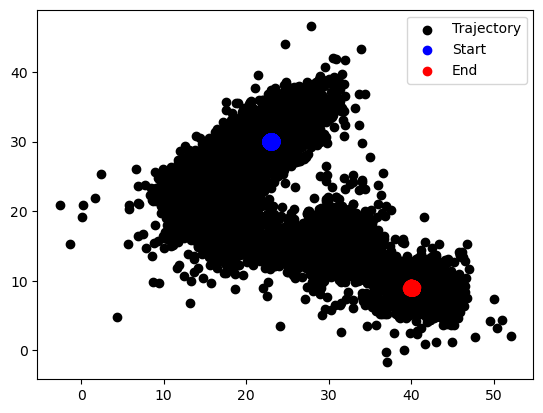

In [28]:
mean = np.load("mb_mean.npy")
std = np.load("mb_std.npy")
all_pos = mean + std*dataset.all_pos.reshape(-1, 1000, 3)[:, :, :2]
# all_pos = dataset.all_pos.reshape(-1, 1000, 3)[:, :, :2]
start = np.array([[23, 30]])
end = np.array([[40, 9]])
start_indicator = np.linalg.norm(all_pos - start, axis=2) < 0.5
end_indicator = np.linalg.norm(all_pos - end, axis=2) < 0.5

start_points = all_pos[start_indicator]
end_points = all_pos[end_indicator]
plt.scatter(all_pos[:, ::10, 0], all_pos[:, ::10, 1], c = "black", label = "Trajectory")

plt.scatter(start_points[:, 0], start_points[:, 1], c = "blue", label = "Start")
plt.scatter(end_points[:, 0], end_points[:, 1], c = "red", label = "End")
plt.legend()

In [30]:
# compute assignments of trajectories to clusters defined by OM path waypoints
def nullspace(A, atol=1e-13, rtol=0):
    #Helper function to obtain null space
    A = np.atleast_2d(A)
    u, s, vh = np.linalg.svd(A)
    tol = max(atol, rtol * s[0])
    nnz = (s >= tol).sum()
    ns = vh[nnz:].conj().T
    ss = s[nnz:]
    return ns, ss

def compute_reweighting_factors(Kmatrix, tol=2e-9):
    """Adapted from https://github.com/muhammadhasyim/tps-torch
    Computes the reweighting factor z_l for each node point by solving an eigenvalue problem
        
    Args:
        Kmatrix (torch.Tensor): [n_path_points, n_path_points] tensor of transition rates between path points during MD simulation.
        tol (float): Tolerance value for the off-diagonal elements of the Kmatrix. Default is 2e-9.
    See Appendix A of paper 
    https://pubs.aip.org/aip/jcp/article/157/18/184111/2842057/Supervised-learning-and-the-finite-temperature for more details.
    """
    
    N = Kmatrix.shape[0]
	#Add tolerance values to the off-diagonal elements
    for i in range(N):
        for j in range(N):
            if abs(i-j) == 1:
                Kmatrix[i, j] += tol
        
    #Build the final matrix
    Kmatrix = Kmatrix.t()-torch.diag(torch.sum(Kmatrix,dim=1)-tol)
    #Compute the reweighting factors using an eigensolver
    v, w = nullspace(Kmatrix.numpy(), atol=tol)
    try:
        index = np.argmin(w)
        zl = np.real(v[:,index])
    except:
        print("Failed")
        #Shift value may not be small enough so we choose a default higher tolerance detection
        v, w = nullspace(Kmatrix.numpy(), atol=10**(-5), rtol=0)
        index = np.argmin(w)
        zl = np.real(v[:,index])
    
    #Normalize
    zl /= np.sum(zl)  
    return zl


# ics = dataset.initial_positions
ics = np.load("initial_positions.npy")*std + mean

distances = torch.linalg.norm(torch.tensor(all_pos.reshape(-1, 2)[:, None]).to(device) - torch.tensor(ics[None]).to(device), dim=-1).cpu().numpy()
cluster_assignments = np.argmin(distances, axis=-1)

# given these cluster assignments, compute the number of transitions between each pair of clusters
n_clusters = len(ics)
transition_counts = np.zeros((n_clusters, n_clusters))
print("Computing transition rates between OM path waypoints")
cluster_assignments = cluster_assignments.reshape(-1, 1000)
for traj in tqdm(range(cluster_assignments.shape[0])):
    for i in range(1, cluster_assignments.shape[1]):
        transition_counts[cluster_assignments[traj, i-1], cluster_assignments[traj, i]] += 1

# find counts for each cluster
# find clusters with nonzero diagonal entries and keep only those
nonzero_clusters = np.where(np.diag(transition_counts) > 0)[0]
ics = ics[nonzero_clusters]

distances = torch.linalg.norm(torch.tensor(all_pos.reshape(-1, 2)[:, None]).to(device) - torch.tensor(ics[None]).to(device), dim=-1).cpu().numpy()
cluster_assignments = np.argmin(distances, axis=-1)

# given these cluster assignments, compute the number of transitions between each pair of clusters
n_clusters = len(ics)
transition_counts = np.zeros((n_clusters, n_clusters))
print("Computing transition rates between OM path waypoints")
cluster_assignments = cluster_assignments.reshape(-1, 1000)
for traj in tqdm(range(cluster_assignments.shape[0])):
    for i in range(1, cluster_assignments.shape[1]):
        transition_counts[cluster_assignments[traj, i-1], cluster_assignments[traj, i]] += 1

transition_counts /= np.sum(transition_counts, axis=1, keepdims=True)


# compute the reweighting factors
master_eqn_reweighting_factors = compute_reweighting_factors(torch.tensor(transition_counts), tol=1e-5)
# make sure no reweighting factors are negative
print(master_eqn_reweighting_factors)
assert np.all(master_eqn_reweighting_factors > 0)


Computing transition rates between OM path waypoints


100%|██████████| 304/304 [00:00<00:00, 2620.67it/s]


Computing transition rates between OM path waypoints


100%|██████████| 304/304 [00:00<00:00, 2681.23it/s]

[4.54628077e-01 5.68665071e-02 1.68198907e-02 1.02932551e-02
 1.01741483e-02 9.03827539e-03 9.71326489e-03 1.04511221e-02
 9.28363763e-03 7.71861559e-03 6.80289259e-03 6.19660302e-03
 6.41486431e-03 7.55216308e-03 3.98148325e-03 3.80335229e-04
 4.27241927e-03 8.16306301e-04 5.22612145e-04 2.91755896e-03
 6.06595637e-03 6.91628354e-03 4.61091559e-03 1.08566014e-02
 4.74236263e-02 6.20467946e-02 2.76653456e-03 2.27907083e-02
 3.66445138e-03 1.98885015e-04 6.23756238e-04 2.21639408e-03
 1.86843114e-04 4.17858236e-04 1.42373486e-03 2.34453633e-02
 5.11357103e-02 6.27446756e-02 3.61190749e-02 1.95018007e-02]


100%|██████████| 304/304 [00:03<00:00, 91.76it/s]


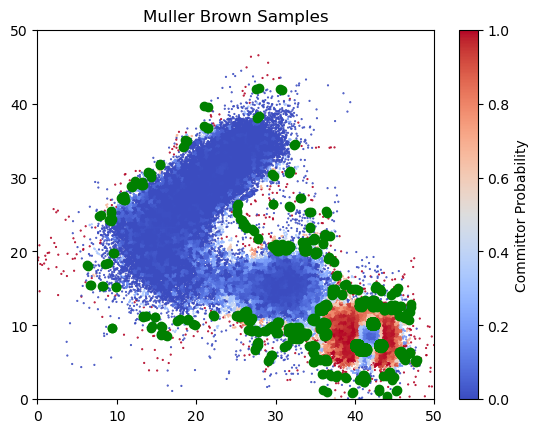

In [31]:
committor_probs  = get_gt_committor_probs(all_pos, start_indicator,end_indicator, calculator)
plot_samples(all_pos.reshape(-1, 2), committor_probs.reshape(-1, 2))

/tmp/ipykernel_282938/1211938320.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mean = torch.tensor(mean).to(device).to(torch.float32)
/tmp/ipykernel_282938/1211938320.py:53: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  std = torch.tensor(mean).to(device).to(torch.float32)
/tmp/ipykernel_282938/1211938320.py:115: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  trainset = torch.utils.data.TensorDataset(torch.tensor(x_train), torch.tensor(start_train), torch.tensor(end_train), torch.tensor(probs_train), torch.tensor(weight_train))
/tmp

Computing empirical committor probabilities from MD simulations


  0%|          | 0/13 [00:00<?, ?it/s]

100%|██████████| 13/13 [00:58<00:00,  4.48s/it]


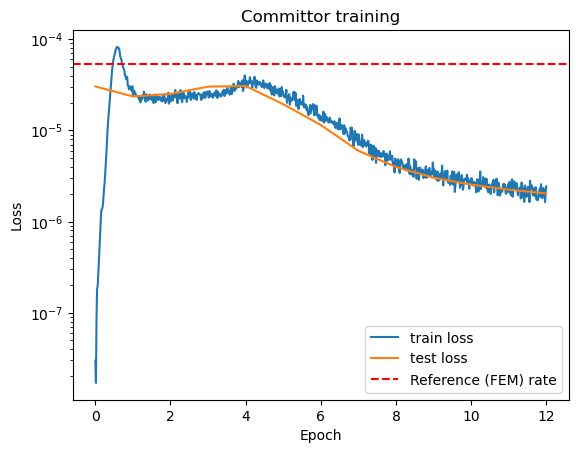

In [33]:
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
import torch.nn as nn
from tqdm import tqdm
from ase import units
from diffusion_likelihood import get_likelihood_fn
from sde_lib import VPSDE
import import_ipynb
from mb_ddpm import MLP, MBDiffusionModel

print("Computing empirical committor probabilities from MD simulations")
# committor_probs  = get_gt_committor_probs(all_pos, start_indicator,end_indicator, calculator)
# plot_samples(all_pos.reshape(-1, 2), committor_probs.reshape(-1, 2))

class CommittorMLP(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, device, act = F.relu):
        super(CommittorMLP, self).__init__()
        self.device = device
        self.in_dim = in_dim
        # self.mean = torch.tensor(train_dataset.mean).to(device).to(torch.float32)
        # self.std = torch.tensor(train_dataset.std).to(device).to(torch.float32)
        mean = torch.tensor(np.load("mb_mean.npy")).to(device).to(torch.float32)
        std = torch.tensor(np.load("mb_std.npy")).to(device).to(torch.float32)

        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim) 
        self.fc3 = nn.Linear(hidden_dim, hidden_dim) 
        self.fc4 = nn.Linear(hidden_dim, hidden_dim) 
        self.act = act
        self.fc5 = nn.Linear(hidden_dim, out_dim)  
        self.sigmoid = torch.nn.Sigmoid()
        # add dropout layer
        # self.dropout = nn.Dropout(0.1)


    def forward(self, x):        
        x = self.act(self.fc1(x))
        # x = self.dropout(x)
        x = self.act(self.fc2(x))
        # x = self.dropout(x)
        x = self.act(self.fc3(x))
        # x = self.dropout(x)
        x = self.act(self.fc4(x))
        # x = self.dropout(x)
        x = self.fc5(x)
        committor_prob = self.sigmoid(x)
        return committor_prob


committor_model = CommittorMLP(2, 64, 1, device).to(device)

mean = torch.tensor(mean).to(device).to(torch.float32)
std = torch.tensor(mean).to(device).to(torch.float32)

# Train the model on the sampled molecules

n_steps = 1000 # number of training steps (keep this constant across data sizes)
batch_size = 4096
max_data_size = 304000
filter_transition = False
sl_loss_coeff = 0.0
grad_loss_coeff = 1.0
start_loss_coeff = 20.0
end_loss_coeff = 20.0
gt_traj = all_pos.reshape(-1, 2)
idxs = np.random.choice(gt_traj.shape[0], max_data_size, replace=False)
optimizer = torch.optim.Adam(committor_model.parameters(), lr=1e-3)
scheduler = linear_warmup_cosine_decay_lr_scheduler(optimizer, warmup_steps = 0, \
                                                        total_steps = n_steps, \
                                                        lr_min=0.7, lr_max=1.0)
n_epochs = int(n_steps / (max_data_size // batch_size))
train_losses = []
test_losses = []

# split sampled_mol and cluster_assignments into train test sets
gt_traj_keep = gt_traj[idxs]
# cluster_assignments_keep = cluster_assignments.reshape(-1)[idxs]

# Option 1: Compute importance-sampling weights (density ratios) from the Muller-Brown potential (assumes we have access to the true potential)
energies = calculator.get_energy(gt_traj_keep)
min_energy = energies.min()
empirical_density, bin_edges_x, bin_edges_y = np.histogram2d(
            gt_traj_keep[:, 0],
            gt_traj_keep[:, 1],
            bins=1000,
            density=True,
    )
# Digitize samples into bins
bins_x = np.digitize(gt_traj_keep[:, 0], bin_edges_x) - 1
bins_y = np.digitize(gt_traj_keep[:, 1], bin_edges_y) - 1

# Clip to ensure all indices are within bounds
bins_x = np.clip(bins_x, 0, 999)
bins_y = np.clip(bins_y, 0, 999)

empirical_density = torch.tensor(empirical_density[bins_x, bins_y])

reweighting_factors_keep = torch.exp(-(energies - min_energy)) / empirical_density # set k_BT = 1
reweighting_factors_keep = reweighting_factors_keep / reweighting_factors_keep.sum()

# reweighting_factors_keep = torch.ones(gt_traj_keep.shape[0])
# Option 2: Compute importance-sampling weights from likelihood estimate of the generative model (doesn't work well right now)
# log_probs = torch.load("mb_log_probs.pt")
# reweighting_factors_keep = torch.exp(log_probs)

# Option 3: Use the reweighting factors computed from the master equation
# reweighting_factors_keep = master_eqn_reweighting_factors[cluster_assignments_keep]

start_mask_keep = start_indicator.reshape(-1, 1)[idxs]
end_mask_keep = end_indicator.reshape(-1, 1)[idxs]

gt_probs_keep = committor_probs.reshape(-1,1)[idxs]

x_train, x_test, start_train, start_test, end_train, end_test, probs_train, probs_test, weight_train, weight_test = train_test_split(gt_traj_keep, start_mask_keep, end_mask_keep, gt_probs_keep, reweighting_factors_keep, test_size=0.2)
trainset = torch.utils.data.TensorDataset(torch.tensor(x_train), torch.tensor(start_train), torch.tensor(end_train), torch.tensor(probs_train), torch.tensor(weight_train))
train_dataloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

testset = torch.utils.data.TensorDataset(torch.tensor(x_test), torch.tensor(start_test), torch.tensor(end_test), torch.tensor(probs_test), torch.tensor(weight_test))
test_dataloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False)

for e in tqdm(range(n_epochs)):
    committor_model.train()
    # if e % 10 == 0:
    #     print("Epoch ", e+1)
    for x, start, end, prob, weights in train_dataloader:
        weights = weights.unsqueeze(-1).to(device)
        optimizer.zero_grad()
        x = x.to(device).requires_grad_(True)
        x = (x - mean) / std
        x = x.to(torch.float32)
        start = start.to(device)
        end = end.to(device)
        prob = prob.to(device)
        if filter_transition:
            transition_mask = torch.logical_and(~start, ~end)
        else:
            transition_mask = torch.ones_like(start)
        pred_prob = committor_model(x)
        grad_prob = torch.autograd.grad(
            outputs=pred_prob,  # [batch_size]
            inputs=x,  # [batch_size, 2]
            grad_outputs=torch.ones_like(pred_prob),
            retain_graph=True,  # Make sure the graph is not destroyed during training
            create_graph=True,  # Create graph for second derivative
            allow_unused=True,
            )[0]
        grad_loss = 0
        start_boundary_loss = 0
        end_boundary_loss = 0

        # if transition_mask.sum() > 0:
        batch_weights = weights[transition_mask]
        batch_weights = batch_weights / batch_weights.sum()
        grad_loss = (batch_weights * (grad_prob/std).square().sum(-1, keepdim = True)[transition_mask]).sum()
        if start.sum() > 0:
            start_boundary_loss = (pred_prob**2)[start].mean()
        if end.sum() > 0:
            end_boundary_loss = ((1 - pred_prob)**2)[end].mean()
        
        sl_loss = (pred_prob - prob).square().mean()

        loss = sl_loss_coeff*sl_loss + start_loss_coeff*start_boundary_loss + end_loss_coeff*end_boundary_loss + grad_loss_coeff*grad_loss

        loss.backward()
        optimizer.step()
        scheduler.step()
        train_losses.append(grad_loss.detach().unsqueeze(-1))
        
    # Test the model on the test set
    committor_model.eval()
    tls = []
    for x, start, end, prob, weights in test_dataloader:
        weights = weights.unsqueeze(-1).to(device)
        x = x.to(device).requires_grad_(True)
        x = (x - mean) / std
        x = x.to(torch.float32)
        start = start.to(device)
        end = end.to(device)
        prob = prob.to(device)
        if filter_transition:
            transition_mask = torch.logical_and(~start, ~end)
        else:
            transition_mask = torch.ones_like(start)
        pred_prob = committor_model(x)
        grad_prob = torch.autograd.grad(
            outputs=pred_prob,  # [batch_size]
            inputs=x,  # [batch_size, 2]
            grad_outputs=torch.ones_like(pred_prob),
            retain_graph=True,  # Make sure the graph is not destroyed during training
            create_graph=True,  # Create graph for second derivative
            allow_unused=True,
            )[0]
        grad_loss = 0
        start_boundary_loss = 0
        end_boundary_loss = 0

        # if transition_mask.sum() > 0:
        
        batch_weights = weights[transition_mask]
        batch_weights = batch_weights / batch_weights.sum()
        grad_loss = (batch_weights * (grad_prob/std).square().sum(-1, keepdim = True)[transition_mask]).sum()
        if start.sum() > 0:
            start_boundary_loss = (pred_prob**2)[start].mean()
        if start.sum() > 0:
            end_boundary_loss = ((1 - pred_prob)**2)[end].mean()

        sl_loss = (pred_prob - prob).square().mean()

        loss = sl_loss_coeff*sl_loss + start_loss_coeff*start_boundary_loss + end_loss_coeff*end_boundary_loss + grad_loss_coeff*grad_loss
        
        tls.append(grad_loss.detach().unsqueeze(-1))
    
    test_loss = torch.cat(tls).sum(0) / len(tls)
    test_losses.append(test_loss.unsqueeze(-1))


train_losses = torch.cat(train_losses).cpu().numpy()
test_losses = torch.cat(test_losses).cpu().numpy()

plot_losses(train_losses, test_losses, "Committor training", reference_rate=5.38e-05)

# Save the model
torch.save(committor_model, f"mb-committor-model.pt")

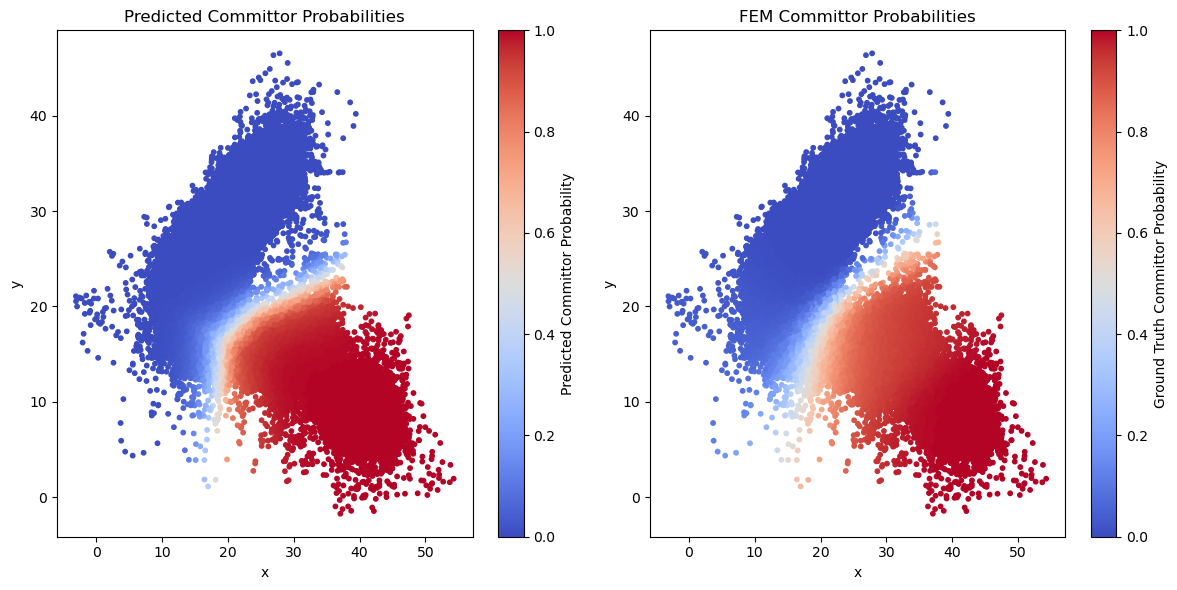

In [34]:
from scipy.spatial import cKDTree

# Compute model predicted committor probabilities by looping over the dataset


committor_model.eval()

committor_probs = []
samples = torch.tensor(gt_traj_keep)
for x in samples.split(batch_size):
    x = x.to(device).requires_grad_(True)
    x = (x - mean) / std
    x = x.to(torch.float32)
    pred_prob = committor_model(x)
    committor_probs.append(pred_prob.detach())

committor_probs = torch.cat(committor_probs).cpu().numpy()


# Load ground truth committor values
fem_committor = np.loadtxt("zz_structured.txt")
n_struct = 100

# Generate the meshgrid
points_x = np.linspace(calculator.Lx, calculator.Hx, n_struct)
points_y = np.linspace(calculator.Ly, calculator.Hy, n_struct)
xx, yy = np.meshgrid(points_x, points_y)

# Flatten the meshgrid to use in KDTree
mesh_points = np.vstack([xx.ravel(), yy.ravel()]).T

# Build a KDTree for nearest neighbor lookup
tree = cKDTree(mesh_points)

# Find the nearest neighbors in the mesh for each sample point
_, nearest_idx = tree.query(samples)

# Extract corresponding ground truth committor values
nearest_committor_values = fem_committor.ravel()[nearest_idx]

# Create a side-by-side plot
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot the predicted committor probabilities
scatter1 = axs[0].scatter(samples[:, 0], samples[:, 1], c=committor_probs, cmap='coolwarm', s=10)
axs[0].set_title('Predicted Committor Probabilities')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
plt.colorbar(scatter1, ax=axs[0], label='Predicted Committor Probability')
scatter1.set_clim(0, 1)

# Plot only the ground truth committor probabilities at the sample points
scatter2 = axs[1].scatter(samples[:, 0], samples[:, 1], c=nearest_committor_values, cmap='coolwarm', s=10)
axs[1].set_title('FEM Committor Probabilities')
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')
plt.colorbar(scatter2, ax=axs[1], label='Ground Truth Committor Probability')
scatter2.set_clim(0, 1)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()




In [35]:
from ase import units
def compute_rates(samples, weights, committor_model, calculator):
    """
    samples: torch.tensor of shape [N_samples, 2]
    weights: torch.tensor of shape [N_samples, 1]
    committor_model: NN trained to predict committor probabilities
    calculator: calculator that returns energies of samples (ideally we won't need this when we get the model log likelihoods working)
    """
    weights = weights / weights.sum()
    # Loop over samples and compute grad of model-predicted committors
    committor_model.eval()
    committor_probs = []
    grad_committor_prob_norms = []
    for x in tqdm(samples.split(128)):
        x = x.to(device).requires_grad_(True)
        x = (x - mean) / std
        x = x.to(torch.float32)
        pred_prob = committor_model(x)
        grad_prob = torch.autograd.grad(
            outputs=pred_prob,  # [batch_size]
            inputs=x,  # [batch_size, 2]
            grad_outputs=torch.ones_like(pred_prob),
            retain_graph=True,  # Make sure the graph is not destroyed during training
            create_graph=True,  # Create graph for second derivative
            allow_unused=True,
            )[0]
        grad_committor_prob_norms.append(1/2 * torch.norm(grad_prob / std, dim=-1)**2)
    
    grad_committor_prob_norms = torch.cat(grad_committor_prob_norms)
    
    # Compute a weighted average of the grad of the committor (this is the rate)
    ensemble_average = (weights * grad_committor_prob_norms).sum()
    rate = ensemble_average # undo the normalization of the input
    N_eff = (-weights * torch.log(weights)).sum().exp()  # effective sample size

    print(f"Rate: {rate.item()}, Effective sample size: {N_eff} out of {len(samples)} samples")
    return rate, N_eff, grad_committor_prob_norms

rate, N_eff, grad_committor_prob_norms = compute_rates(torch.tensor(gt_traj_keep), torch.tensor(reweighting_factors_keep).to(device), committor_model, calculator)



/tmp/ipykernel_282938/1192495651.py:39: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  rate, N_eff, grad_committor_prob_norms = compute_rates(torch.tensor(gt_traj_keep), torch.tensor(reweighting_factors_keep).to(device), committor_model, calculator)
  0%|          | 0/2375 [00:00<?, ?it/s]

100%|██████████| 2375/2375 [00:02<00:00, 1139.84it/s]

Rate: 1.046964684063063e-06, Effective sample size: 118811.21768204427 out of 304000 samples


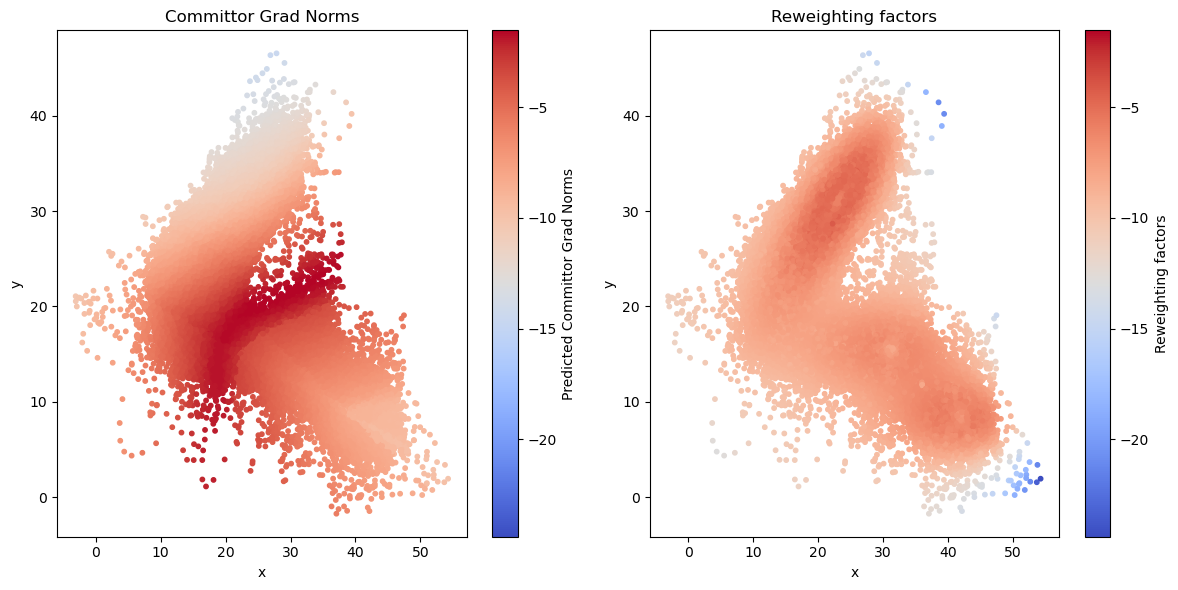

In [36]:
import matplotlib.pyplot as plt

# Create a side-by-side plot
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Compute log-scaled values safely
committor_grad_norms_log = grad_committor_prob_norms.detach().cpu().log10()
reweighting_factors_log = reweighting_factors_keep.detach().cpu().log10()

# Define color limits
vmin, vmax = min(committor_grad_norms_log.min(), reweighting_factors_log.min()), max(committor_grad_norms_log.max(), reweighting_factors_log.max())

# Plot the predicted committor probabilities
scatter1 = axs[0].scatter(samples[:, 0], samples[:, 1], c=committor_grad_norms_log, cmap='coolwarm', s=10, vmin=vmin, vmax=vmax)
axs[0].set_title('Committor Grad Norms')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
cbar1 = plt.colorbar(scatter1, ax=axs[0], label='Predicted Committor Grad Norms')

# Plot only the ground truth committor probabilities at the sample points
scatter2 = axs[1].scatter(samples[:, 0], samples[:, 1], c=reweighting_factors_log, cmap='coolwarm', s=10, vmin=vmin, vmax=vmax)
axs[1].set_title('Reweighting factors')
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')
cbar2 = plt.colorbar(scatter2, ax=axs[1], label='Reweighting factors')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()


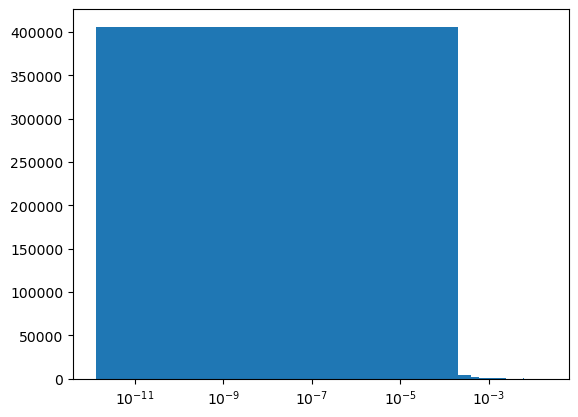